In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Re-import tensorflow after setting the environment variable
import tensorflow as tf
from tensorflow import keras

I0000 00:00:1777122714.958356  111701 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

### Dataset Characteristics:
Number of instances: 20640
Number of attributes: 8 numeric, predictive attributes and the target
Target: Median house value for California districts, expressed in hundreds of thousands of dollars ($100,000).
### Attribute Information:
1. MedInc: median income in block group
2. HouseAge: median house age in block group
3. AveRooms: average number of rooms per household
4. AveBedrms: average number of bedrooms per household
5. Population: block group population
6. AveOccup: average number of household members
7. Latitude: block group latitude
8. Longitude: block group longitude
##### Missing Attribute Values: None
Documentation: https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset


In [4]:
print(housing.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [5]:
from sklearn.model_selection import train_test_split
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [7]:
np.random.seed(42)
tf.random.set_seed(42)

In [8]:
X_train.shape

(11610, 8)

In [9]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])
# keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
model.summary()

/home/malve/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777122752.793232  111701 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
I0000 00:00:1777122752.793275  111701 cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
I0000 00:00:1777122752.793292  111701 cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
I0000 00:00:1777122752.793296  111701 cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
I0000 00:00:1777122752.7

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,231 (4.81 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss="mean_squared_error", 
                optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["mae"]) # mean_absolute_error

In [11]:
model_history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.8896 - mae: 1.0119 - val_loss: 0.9686 - val_mae: 0.7528
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8438 - mae: 0.6907 - val_loss: 0.8072 - val_mae: 0.6764
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7515 - mae: 0.6439 - val_loss: 0.7445 - val_mae: 0.6416
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7015 - mae: 0.6178 - val_loss: 0.7027 - val_mae: 0.6192
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6656 - mae: 0.5999 - val_loss: 0.6710 - val_mae: 0.6028
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6380 - mae: 0.5863 - val_loss: 0.6458 - val_mae: 0.5896
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6158 - mae: 0.5755 - val_loss: 0.6250 - val_mae: 0.5790
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5974 - mae: 0.5666 - val_loss: 0.6072 - val_mae: 0.5702
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [12]:
mae_test = model.evaluate(X_test, y_test)
print("MAE on test set:", mae_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4823 - mae: 0.5045
MAE on test set: [0.48229745030403137, 0.5044790506362915]


In [13]:
model_history.history

{'loss': [1.8895986080169678,
  0.8437581658363342,
  0.7515155076980591,
  0.7014669179916382,
  0.665635883808136,
  0.6379860639572144,
  0.6158355474472046,
  0.5974451899528503,
  0.5818638801574707,
  0.5684237480163574,
  0.5565655827522278,
  0.545822262763977,
  0.5360031127929688,
  0.5269045233726501,
  0.5184162259101868,
  0.5105115175247192,
  0.503251850605011,
  0.4966479241847992,
  0.49053722620010376,
  0.4848702549934387],
 'mae': [1.0118939876556396,
  0.6907481551170349,
  0.6438660025596619,
  0.6177654266357422,
  0.5998862981796265,
  0.586331844329834,
  0.5755246877670288,
  0.566559910774231,
  0.5588504076004028,
  0.5521559715270996,
  0.5460749864578247,
  0.5405029654502869,
  0.5353706479072571,
  0.5304427742958069,
  0.5257298350334167,
  0.5211858749389648,
  0.5169124007225037,
  0.5129335522651672,
  0.5092395544052124,
  0.5057118535041809],
 'val_loss': [0.9686139822006226,
  0.8071525692939758,
  0.7444972395896912,
  0.7026645541191101,
  0.671

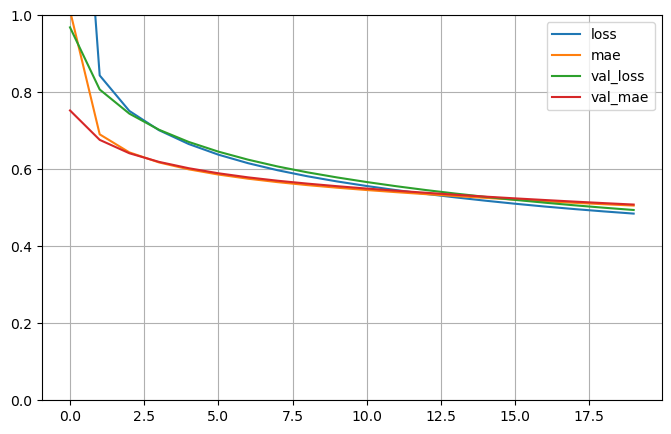

In [14]:
pd.DataFrame(model_history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [15]:
X_new = X_test[:3]
y_pred = model.predict(X_new)
print("Predictions:\n", y_pred)
print("Actual values:\n", y_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predictions:
 [[1.9722052]
 [1.7234704]
 [3.7161121]]
Actual values:
 [2.25    1.783   5.00001]


### Functional API

In [16]:
del model # deletes the model to free up memory

In [17]:
keras.backend.clear_session() # This is useful to avoid clutter from old models and layers, especially when memory is limited.

### Functional API
Not all models are simple stacks of layers. The functional API lets you build complex models, such as multi-output models, directed acyclic graphs, or models with shared layers.

In [18]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input_], outputs=[output])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        270 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,239 (4.84 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss="mean_squared_error", 
                optimizer=keras.optimizers.SGD(learning_rate=1e-3),
              metrics=["mae"]) # mean_absolute_error

In [20]:
model_history = model.fit(X_train, y_train, epochs=40, validation_data=(X_valid, y_valid))

Epoch 1/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.9870 - mae: 0.9795 - val_loss: 0.7081 - val_mae: 0.6127
Epoch 2/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6572 - mae: 0.5921 - val_loss: 0.6427 - val_mae: 0.5897
Epoch 3/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6191 - mae: 0.5732 - val_loss: 0.6105 - val_mae: 0.5713
Epoch 4/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5920 - mae: 0.5589 - val_loss: 0.5865 - val_mae: 0.5573
Epoch 5/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5715 - mae: 0.5475 - val_loss: 0.5670 - val_mae: 0.5461
Epoch 6/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5547 - mae: 0.5385 - val_loss: 0.5514 - val_mae: 0.5369
Epoch 7/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5413 - mae: 0.5312 - val_loss: 0.5387 - val_mae: 0.5296
Epoch 8/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5302 - mae: 0.5253 - val_loss: 0.5283 - val_mae: 0.5236
Epoch 9/40
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [21]:
mae_test = model.evaluate(X_test, y_test)
print("MAE on test set:", mae_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4320 - mae: 0.4686
MAE on test set: [0.43203186988830566, 0.4686427414417267]


In [22]:
model_history.history

{'loss': [1.9870439767837524,
  0.6571673154830933,
  0.6191332340240479,
  0.5919929146766663,
  0.5714935660362244,
  0.5546651482582092,
  0.5412638187408447,
  0.5301952958106995,
  0.5209847688674927,
  0.5132129192352295,
  0.5063217282295227,
  0.5006599426269531,
  0.4956771433353424,
  0.4910993278026581,
  0.4870465397834778,
  0.48315101861953735,
  0.48001623153686523,
  0.4768971800804138,
  0.4739900827407837,
  0.47135117650032043,
  0.4687173068523407,
  0.46655771136283875,
  0.46436306834220886,
  0.46219736337661743,
  0.46009355783462524,
  0.4582359194755554,
  0.4563019275665283,
  0.4543904960155487,
  0.45252278447151184,
  0.45076611638069153,
  0.4490149915218353,
  0.44728371500968933,
  0.44565925002098083,
  0.4440739154815674,
  0.4424784779548645,
  0.44089117646217346,
  0.43931108713150024,
  0.4375760853290558,
  0.4360766112804413,
  0.43448981642723083],
 'mae': [0.9794649481773376,
  0.5920777916908264,
  0.5732367038726807,
  0.5589131712913513,
  

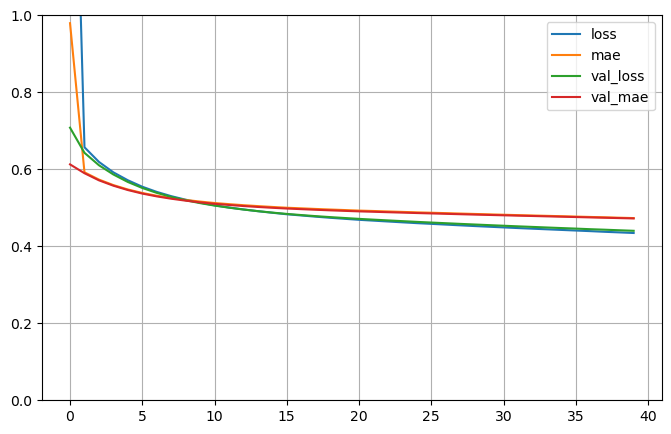

In [23]:
pd.DataFrame(model_history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

## Saving and Restoring Models

In [24]:
#model.save("my_Func_model.h5") # Legacy way to save Keras models, using the HDF5 format. It is still supported but the native Keras format is now recommended.
model.save("my_Func_model.keras") # New way to save Keras models, using the native Keras format. It is recommended over the older HDF5 format.
# Only save a model after training it, otherwise you will just save the untrained model. You can load the model later and use it to make predictions without having to retrain it.

In [25]:
%pwd

'/home/malve/development/ML/machine-learning-python-r'

In [26]:
del model
keras.backend.clear_session()

In [27]:
#model = keras.models.load_model("my_Func_model.h5") # Load the model saved in HDF5 format. If you saved it in the newer Keras format, use "my_Func_model.keras" instead.
model = keras.models.load_model("my_Func_model.keras") # Load the model saved in the newer Keras format. If you saved it in the older HDF5 format, use "my_Func_model.h5" instead.
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30)        │        270 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30)        │        930 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 38)        │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         39 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,241 (4.85 KB)

 Trainable params: 1,239 (4.84 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [28]:
y_pred = model.predict(X_new)
print("Predictions:\n", y_pred)
print("Actual values:\n", y_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predictions:
 [[2.0269043]
 [1.5866483]
 [3.8346643]]
Actual values:
 [2.25    1.783   5.00001]


### Using Callbacks during Training

In [29]:
del model
keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [30]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])
model.summary()

/home/malve/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,231 (4.81 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

In [32]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("Model-{epoch:02d}.keras", save_best_only=True)

In [33]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid), callbacks=[checkpoint_cb])

Epoch 1/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.7140 - val_loss: 0.8042
Epoch 2/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7298 - val_loss: 0.6978
Epoch 3/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6644 - val_loss: 0.6501
Epoch 4/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6248 - val_loss: 0.6145
Epoch 5/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5935 - val_loss: 0.5853
Epoch 6/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5680 - val_loss: 0.5612
Epoch 7/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5469 - val_loss: 0.5412
Epoch 8/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5292 - val_loss: 0.5244
Epoch 9/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5145 - val_loss: 0.5105
Epoch 10/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5025 - val_loss: 0.4990
Epoch 11/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4924 - val_loss: 0.4895
Epoch 12/20
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [34]:
del model
keras.backend.clear_session()

In [35]:
model = keras.models.load_model("Model-20.keras") # Load the model saved in HDF5 format. If you saved it in the newer Keras format, use "my_Func_model.keras" instead.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233 (4.82 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [36]:
mse_test = model.evaluate(X_test, y_test)
print("MSE on test set:", mse_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4462
MSE on test set: 0.44618284702301025


### Best Model Only

In [37]:
del model
keras.backend.clear_session()

In [38]:
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,231 (4.81 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(loss="mean_squared_error", optimizer=keras.optimizers.SGD(learning_rate=1e-3))

In [40]:
#checkpoint_cb = keras.callbacks.ModelCheckpoint("Best_Model.keras", save_best_only=True)
checkpoint_cb = keras.callbacks.ModelCheckpoint("early_stopping.keras", save_best_only=True)

In [41]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
# patience=10 means that if the validation loss does not improve for 10 consecutive epochs, the training will stop. restore_best_weights=True means that after stopping, the model will restore the weights from the epoch with the best validation loss.

In [42]:
history = model.fit(X_train, y_train, 
                    epochs=200, validation_data=(X_valid, y_valid), 
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.1958 - val_loss: 1.1596
Epoch 2/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9762 - val_loss: 0.9008
Epoch 3/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.8188 - val_loss: 0.8007
Epoch 4/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7504 - val_loss: 0.7433
Epoch 5/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7055 - val_loss: 0.7017
Epoch 6/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6704 - val_loss: 0.6684
Epoch 7/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6413 - val_loss: 0.6406
Epoch 8/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6164 - val_loss: 0.6166
Epoch 9/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5949 - val_loss: 0.5957
Epoch 10/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5761 - val_loss: 0.5773
Epoch 11/200
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5593 - val_loss: 0.5610
Epoch 12/200
363/363 ━━━━━━━━━━━━━━━━━━━━

In [43]:
del model
keras.backend.clear_session()

In [44]:
model = keras.models.load_model("early_stopping.keras") # Load the model saved in keras format. If you saved it in the older HDF5 format, use "my_Func_model.h5" instead.
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           270 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │           930 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233 (4.82 KB)

 Trainable params: 1,231 (4.81 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [45]:
mse_test = model.evaluate(X_test, y_test)
print("MSE on test set:", mse_test) # The MSE on the test set is the mean squared error of the model's predictions on the test set compared to the actual target values. A lower MSE indicates better performance of the model.

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3262
MSE on test set: 0.3262467086315155
